C:\Users\Administrator\AppData\Local\Temp\ipykernel_9468\1824462696.py:53: OptimizeWarning: Covariance of the parameters could not be estimated
  params2, _ = curve_fit(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9468\1824462696.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  params3, _ = curve_fit(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9468\1824462696.py:98: OptimizeWarning: Covariance of the parameters could not be estimated
  params4, _ = curve_fit(phase4_model, x4s, y4)


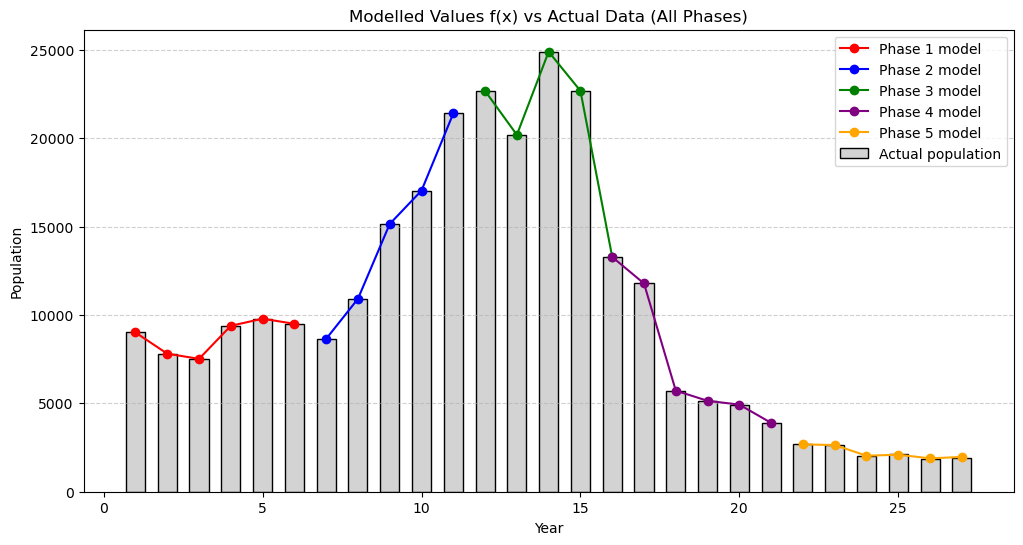

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# ORIGINAL DATA
# =========================================================
years = np.arange(1, 28)
population = np.array([
    9012, 7812, 7519, 9389, 9792, 9502,
    8651, 10918, 15155, 17042, 21410,
    22681, 20196, 24901, 22687,
    13283, 11785, 5719, 5145, 4929,
    3896, 2678, 2633, 2022, 2140,
    1862, 1922
])

# =========================================================
# PHASE 1 — ITERATION 4
# =========================================================
x1 = np.array([1, 2, 3, 4, 5, 6])
y1 = population[:6]

def midline_p1(x):
    return -220.623884*x**2 + 2277.85991*x + 3792.176103

B1, C1 = -1.671427, 3.512121

res1 = y1 - midline_p1(x1)
sin1 = np.sin(B1*x1 + C1)
mask1 = np.abs(sin1) > 0.1

def amp_p1(x, a2, a1, a0):
    return a2*x**2 + a1*x + a0

params1, _ = curve_fit(amp_p1, x1[mask1], res1[mask1]/sin1[mask1])
a2_1, a1_1, a0_1 = params1

def phase1(x):
    return midline_p1(x) + amp_p1(x, a2_1, a1_1, a0_1)*np.sin(B1*x + C1)

fx1 = phase1(x1)

# =========================================================
# PHASE 2 — ITERATION 3
# =========================================================
x2 = np.array([7, 8, 9, 10, 11])
y2 = population[6:11]

def sinusoidal_linear(x, m, c, A, B, C):
    return (m*x + c) + A*np.sin(B*x + C)

params2, _ = curve_fit(
    sinusoidal_linear, x2, y2,
    p0=[1, 1, 1000, 1, 0]
)
m2, c2, A2, B2, C2 = params2

phase2 = lambda x: sinusoidal_linear(x, m2, c2, A2, B2, C2)
fx2 = phase2(x2)

# =========================================================
# PHASE 3 — ITERATION 3
# =========================================================
x3 = np.array([12, 13, 14, 15, 16])
y3 = population[11:16]

params3, _ = curve_fit(
    sinusoidal_linear, x3, y3,
    p0=[1, 1, 1000, 1, 0]
)
m3, c3, A3, B3, C3 = params3

phase3 = lambda x: sinusoidal_linear(x, m3, c3, A3, B3, C3)
fx3 = phase3(x3)

# =========================================================
# PHASE 4 — ITERATION 4 (DIRECT FIT)
# =========================================================
x4 = np.array([16, 17, 18, 19, 20, 21])
y4 = population[15:21]

def midline_p4(x):
    return (
        31.0463*x**3
        - 1263.6944*x**2
        + 12778.0688*x
        + 5651.3016
    )

B4, C4 = -16.8125, 158.9276
x4s = x4 - 16

def phase4_model(x, a5, a4, a3, a2, a1, a0):
    A = a5*x**5 + a4*x**4 + a3*x**3 + a2*x**2 + a1*x + a0
    return midline_p4(x + 16) + A*np.sin(B4*(x + 16) + C4)

params4, _ = curve_fit(phase4_model, x4s, y4)
a5, a4_, a3_, a2_, a1_, a0_ = params4

def phase4(x):
    xs = x - 16
    A = a5*xs**5 + a4_*xs**4 + a3_*xs**3 + a2_*xs**2 + a1_*xs + a0_
    return midline_p4(x) + A*np.sin(B4*x + C4)

fx4 = phase4(x4)

# =========================================================
# PHASE 5 — ITERATION 4
# =========================================================
x5 = np.array([22, 23, 24, 25, 26, 27])
y5 = population[21:]

def midline_p5(x):
    return 6.216845*x**2 - 472.859446*x + 10000

B5, C5 = 2.264505, -40.245211

res5 = y5 - midline_p5(x5)
sin5 = np.sin(B5*x5 + C5)
mask5 = np.abs(sin5) > 0.1

def amp_p5(x, a2, a1, a0):
    return a2*x**2 + a1*x + a0

params5, _ = curve_fit(amp_p5, x5[mask5], res5[mask5]/sin5[mask5])
a2_5, a1_5, a0_5 = params5

def phase5(x):
    return midline_p5(x) + amp_p5(x, a2_5, a1_5, a0_5)*np.sin(B5*x + C5)

fx5 = phase5(x5)

# =========================================================
# PLOTTING — BARS FOR ACTUAL DATA
# =========================================================
plt.figure(figsize=(12, 6))

# Actual population as bars
plt.bar(
    years,
    population,
    width=0.6,
    color="lightgrey",
    edgecolor="black",
    label="Actual population",
    zorder=1
)

# Phase model values (lines + markers)
plt.plot(x1, fx1, '-o', color="red", label="Phase 1 model", zorder=3)
plt.plot(x2, fx2, '-o', color="blue", label="Phase 2 model", zorder=3)
plt.plot(x3, fx3, '-o', color="green", label="Phase 3 model", zorder=3)
plt.plot(x4, fx4, '-o', color="purple", label="Phase 4 model", zorder=3)
plt.plot(x5, fx5, '-o', color="orange", label="Phase 5 model", zorder=3)

plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Modelled Values f(x) vs Actual Data (All Phases)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()
